# Backtesting the expected-minutes model on the 2025/26 season

Compares the two-stage `MinutesModel` (`airsenal.framework.minutes_model`) against the old baseline it
replaced: `own_recent_minutes`, the mean of a player's own last 3 matches' minutes, which is what the
previous prediction code implicitly used as its estimate of expected minutes (see git history of
`prediction_utils.calc_predicted_points_for_player`).

`MinutesModel` classifies each row into a minutes bucket (`0`, `1-59`, `60-89`, `90`) and regresses the
actual value within the two partial buckets, combining the result into one continuous expected-minutes
number as a probability-weighted mixture. It also uses `absent_teammates_typical_minutes` - the summed
*typical* minutes (when actually playing) of same-position teammates who are currently unavailable, rather
than a blind count of how many are absent - so a nailed-on starter's injury counts for much more than a
fringe player's.

We hold out the completed 2025/26 season (`season == "2526"`) entirely and refit the model on every other
past season, so this is a genuine out-of-season backtest rather than training-set performance. 2025/26 is
used as the test season (rather than the current, in-progress season) because it's fully finished and so
has reliable per-gameweek `Absence` records - the in-progress season only has *live*, as-of-today
availability status, which wouldn't reflect what was actually known at each past gameweek.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from airsenal.framework.minutes_model import MinutesModel, build_minutes_feature_frame
from airsenal.framework.schema import session

## Build the feature frame

One query across all seasons we have `PlayerScore` data for; we split it by season below. This is the
same feature engineering used in production (`fit_minutes_model`/`build_minutes_training_data`), just kept
at full (player_id, season, gameweek) granularity here so we can hold out a specific season ourselves.

In [2]:
feature_frame = build_minutes_feature_frame(dbsession=session)
feature_frame["season"].value_counts().sort_index()

Filling history dataframe for Raya: 0/1534 done
Filling history dataframe for Arrizabalaga: 1/1534 done
Filling history dataframe for Meslier: 2/1534 done
Filling history dataframe for Gabriel: 3/1534 done
Filling history dataframe for J.Timber: 4/1534 done
Filling history dataframe for Saliba: 5/1534 done
Filling history dataframe for Lewis-Skelly: 6/1534 done
Filling history dataframe for Calafiori: 7/1534 done
Filling history dataframe for Hincapie: 8/1534 done
Filling history dataframe for White: 9/1534 done
Filling history dataframe for Mosquera: 10/1534 done
Filling history dataframe for Saka: 11/1534 done
Filling history dataframe for Rice: 12/1534 done
Filling history dataframe for Eze: 13/1534 done
Filling history dataframe for Ødegaard: 14/1534 done
Filling history dataframe for Madueke: 15/1534 done
Filling history dataframe for Merino: 16/1534 done
Filling history dataframe for Martinelli: 17/1534 done
Filling history dataframe for Zubimendi: 18/1534 done
Filling history da

Filling history dataframe for Julio Enciso Espínola: 699/1534 done
Filling history dataframe for Brajan Gruda: 700/1534 done
Filling history dataframe for Abdallah Sima: 701/1534 done
Filling history dataframe for James Milner: 702/1534 done
Filling history dataframe for Jeremy Sarmiento Morante: 703/1534 done
Filling history dataframe for Malick Yalcouyé: 704/1534 done
Filling history dataframe for Joe Knight: 705/1534 done
Filling history dataframe for Adrian Mazilu: 706/1534 done
Filling history dataframe for Andrew Moran: 707/1534 done
Filling history dataframe for Freddie Simmonds: 708/1534 done
Filling history dataframe for Gabriel Słonina: 709/1534 done
Filling history dataframe for Marc Cucurella Saseta: 710/1534 done
Filling history dataframe for Christopher Nkunku: 711/1534 done
Filling history dataframe for Mykhailo Mudryk: 712/1534 done
Filling history dataframe for Kendry Páez Andrade: 713/1534 done
Filling history dataframe for Landon Emenalo: 714/1534 done
Filling histor

season
2324    28300
2425    26325
2526    28444
Name: count, dtype: int64

## Train/test split

Hold out 2025/26 completely - train the model on every other season only.

In [3]:
TEST_SEASON = "2526"

train_df = feature_frame[feature_frame["season"] != TEST_SEASON]
test_df = feature_frame[feature_frame["season"] == TEST_SEASON].copy()

print(f"train rows: {len(train_df)}, test rows: {len(test_df)}")
train_df["season"].value_counts().sort_index()

train rows: 54625, test rows: 28444


season
2324    28300
2425    26325
Name: count, dtype: int64

## Fit the new model and compare against the baseline

Baseline = `own_recent_minutes` (mean of the player's own last 3 matches) - directly comparable to the new
model's prediction since both are estimates of the same target: `minutes` in the held-out fixture.

In [4]:
model = MinutesModel().fit(train_df)

test_df["baseline_pred"] = test_df["own_recent_minutes"]
test_df["model_pred"] = model.predict(test_df)
test_df["baseline_error"] = (test_df["baseline_pred"] - test_df["minutes"]).abs()
test_df["model_error"] = (test_df["model_pred"] - test_df["minutes"]).abs()

test_df[
    [
        "own_recent_minutes",
        "absent_teammates_typical_minutes",
        "position",
        "minutes",
        "baseline_pred",
        "model_pred",
    ]
].head()

,own_recent_minutes,absent_teammates_typical_minutes,position,minutes,baseline_pred,model_pred
76,90.0,0.0,GK,90,90.0,83.578147
77,90.0,0.0,GK,90,90.0,83.578147
78,90.0,0.0,GK,90,90.0,83.578147
79,90.0,0.0,GK,90,90.0,83.578147
80,90.0,0.0,GK,90,90.0,83.578147


## Overall error metrics

In [5]:
def summarise(df, label):
    mae_baseline = df["baseline_error"].mean()
    mae_model = df["model_error"].mean()
    rmse_baseline = np.sqrt((df["baseline_pred"] - df["minutes"]).pow(2).mean())
    rmse_model = np.sqrt((df["model_pred"] - df["minutes"]).pow(2).mean())
    print(f"{label} (n={len(df)})")
    print(f"  MAE  baseline={mae_baseline:.2f}  model={mae_model:.2f}")
    print(f"  RMSE baseline={rmse_baseline:.2f}  model={rmse_model:.2f}")


summarise(test_df, "All rows")

All rows (n=28444)
  MAE  baseline=11.73  model=14.10
  RMSE baseline=24.00  model=23.19


## Where the new model should help most: rows with an absent competitor

The baseline ignores teammate availability entirely, so this is the subset where we'd expect the new
model to pull ahead - and the split where the old zero-heavy-history bug (see the module docstring in
`minutes_model.py`) used to bite hardest.

In [6]:
has_absent_competitor = test_df["absent_teammates_typical_minutes"] > 0

summarise(test_df[has_absent_competitor], "Rows with >=1 absent same-position teammate")
summarise(test_df[~has_absent_competitor], "Rows with no absent teammates")

pct = has_absent_competitor.mean()
print(f"\n{pct:.1%} of rows have at least one absent same-position teammate")

Rows with >=1 absent same-position teammate (n=8719)
  MAE  baseline=12.37  model=14.70
  RMSE baseline=24.22  model=23.40
Rows with no absent teammates (n=19725)
  MAE  baseline=11.45  model=13.83
  RMSE baseline=23.90  model=23.10

30.7% of rows have at least one absent same-position teammate


## Plots

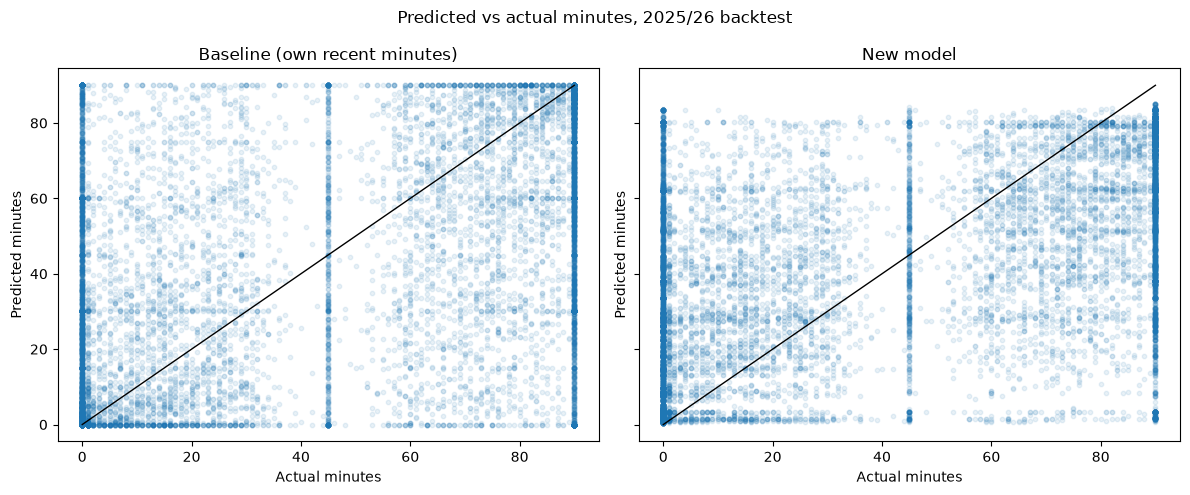

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax, col, title in zip(
    axes,
    ["baseline_pred", "model_pred"],
    ["Baseline (own recent minutes)", "New model"],
    strict=True,
):
    ax.scatter(test_df["minutes"], test_df[col], alpha=0.1, s=10)
    ax.plot([0, 90], [0, 90], color="black", linewidth=1)
    ax.set_xlabel("Actual minutes")
    ax.set_ylabel("Predicted minutes")
    ax.set_title(title)
fig.suptitle("Predicted vs actual minutes, 2025/26 backtest")
fig.tight_layout()

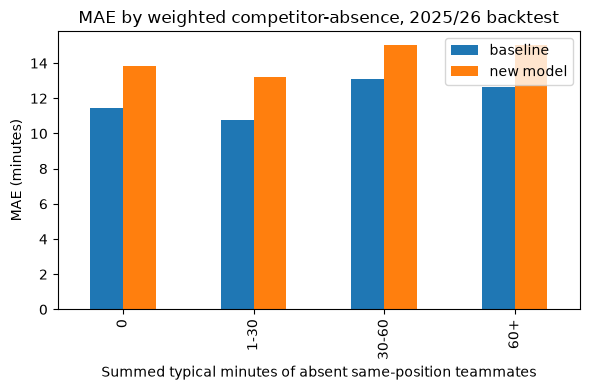

In [8]:
bucket = pd.cut(
    test_df["absent_teammates_typical_minutes"],
    bins=[-1, 0, 30, 60, 1000],
    labels=["0", "1-30", "30-60", "60+"],
)
mae_by_bucket = (
    test_df.assign(bucket=bucket)
    .groupby("bucket", observed=True)[["baseline_error", "model_error"]]
    .mean()
    .rename(columns={"baseline_error": "baseline", "model_error": "new model"})
)

mae_by_bucket.plot(kind="bar", figsize=(6, 4))
plt.ylabel("MAE (minutes)")
plt.xlabel("Summed typical minutes of absent same-position teammates")
plt.title("MAE by weighted competitor-absence, 2025/26 backtest")
plt.tight_layout()

## Why MAE still doesn't beat baseline, despite RMSE improving

The two-stage design was meant to fix the old single regressor's tendency to smooth
toward the middle - and it does move RMSE in the right direction (23.19 vs baseline's
24.00, and better than the old single-regressor's 23.16). But MAE is still worse than
baseline (14.10 vs 11.73), and the scatter plot still shows predictions rarely reaching
a confident 0 or 90.

The reason is a property of the aggregation, not a bug: `MinutesModel.predict()`
combines the classifier and regressors as a **probability-weighted mean**
(`(proba * point_estimates).sum(axis=1)`) - i.e. it targets `E[minutes]`. RMSE is
minimised by the conditional mean, so that's exactly what improved. MAE, however, is
minimised by the conditional **median** (or more loosely, the mode, for a
sharply-peaked distribution) - and real minutes are close to a two-point distribution
(mostly ~0 or ~90), so the mode/median is usually one of those extremes even when there
is genuine uncertainty. The baseline (last 3 matches' actual minutes) is effectively a
persistence forecast, and football is autocorrelated enough match-to-match that
"whatever happened recently" already lands on the mode most of the time - which is why
it's hard to beat on MAE specifically, even with a worse RMSE.

Which one matters more depends on what happens downstream: `get_attacking_points`/
`get_defending_points` ([prediction_utils.py:287](../airsenal/framework/prediction_utils.py#L287))
are *close to linear* in `minutes` (not exact, but the dominant term is), so
`E[points(minutes)] ≈ points(E[minutes])` is a reasonable approximation - meaning the
mean-based mixture this model computes is arguably the more appropriate quantity to
feed into the points formulas, even though it looks worse on this minutes-only MAE
comparison. Flagging this rather than picking a side: it's a real modelling choice
(mean vs. mode aggregation) with a genuine trade-off, not a settled result.

## Points-level backtest: predicted vs actual FPL points

Everything above only evaluates *minutes* accuracy in isolation. What actually matters
is the full predicted-points pipeline (`fill_predictedscore_table.calc_all_predicted_points`),
which feeds the two-stage `MinutesModel`'s output through the same team/player Bayesian
models and scoring formulas used in production. Here we run that full pipeline for a
sample of gameweeks across the completed 2025/26 season and compare
`PlayerPrediction.predicted_points` against the real `PlayerScore.points` for the same
player/fixture.

This is a **walk-forward** backtest, not a single held-out split like the minutes
comparison above: predicting gameweek `gw` fits the team/player/minutes models on
everything known up to `gw` (including earlier 2025/26 gameweeks), which is exactly
what the live system would have had available at the time - realistic, but not
directly comparable to the controlled train/test split used earlier in this notebook.

Each gameweek's full model fit takes about a minute, so we sample gameweeks spread
across the season rather than backtesting all 38 - this writes real `PlayerPrediction`
rows into the local dev database, tagged with `POINTS_BACKTEST_TAG_PREFIX` below so
they're easy to identify or clean up afterwards.

In [9]:
%%capture
from airsenal.scripts.fill_predictedscore_table import make_predictedscore_table

POINTS_BACKTEST_GAMEWEEKS = [5, 9, 13, 17, 21, 25, 29, 33, 37]
POINTS_BACKTEST_TAG_PREFIX = "notebook_points_backtest_"

prediction_tags = {}
for gw in POINTS_BACKTEST_GAMEWEEKS:
    prediction_tags[gw] = make_predictedscore_table(
        gw_range=[gw],
        season=TEST_SEASON,
        tag_prefix=f"{POINTS_BACKTEST_TAG_PREFIX}{gw}_",
        dbsession=session,
    )

In [10]:
prediction_tags

{5: 'notebook_points_backtest_5_96aea54d-336e-4312-a37c-f6631559c0fa',
 9: 'notebook_points_backtest_9_8f52e9ab-4645-4d03-9a69-359b7c51e30c',
 13: 'notebook_points_backtest_13_b38d7f44-ebe3-4ca2-9e7a-a147650ef20a',
 17: 'notebook_points_backtest_17_f6a8f0db-d5e2-4412-9d63-feb59a48804a',
 21: 'notebook_points_backtest_21_e9139164-eb20-4fbc-bed1-25fac0da7e1e',
 25: 'notebook_points_backtest_25_0281bb38-682d-40c7-a36d-968e4b0c3621',
 29: 'notebook_points_backtest_29_dd3a378f-3b38-4d8c-be3e-e81712562520',
 33: 'notebook_points_backtest_33_4ab2556d-742e-4db3-a407-bd2f8a854f2d',
 37: 'notebook_points_backtest_37_796dea1c-576c-4510-b03f-9d76751d4530'}

In [11]:
from sqlalchemy import select

from airsenal.framework.schema import PlayerPrediction, PlayerScore

points_rows = []
for gw, tag in prediction_tags.items():
    query = (
        select(
            PlayerPrediction.player_id,
            PlayerPrediction.predicted_points,
            PlayerScore.points,
            PlayerScore.minutes,
        )
        .join(
            PlayerScore,
            (PlayerScore.player_id == PlayerPrediction.player_id)
            & (PlayerScore.fixture_id == PlayerPrediction.fixture_id),
        )
        .where(PlayerPrediction.tag == tag)
    )
    for player_id, predicted_points, actual_points, actual_minutes in session.execute(
        query
    ).all():
        points_rows.append(
            {
                "gameweek": gw,
                "player_id": player_id,
                "predicted_points": predicted_points,
                "actual_points": actual_points,
                "actual_minutes": actual_minutes,
            }
        )

points_df = pd.DataFrame(points_rows)
points_df.shape

(7361, 5)

### Save results for comparison against the old baseline

Writing this out now so we can switch to the pre-minutes-model branch, regenerate the
same predicted-vs-actual comparison with the old "average recent minutes" approach for
the same gameweeks/players, and diff the two CSVs side by side afterwards.

In [12]:
from airsenal.framework.schema import Player

player_names = dict(session.execute(select(Player.player_id, Player.name)).all())

points_df_out = points_df.copy()
points_df_out.insert(2, "player_name", points_df_out["player_id"].map(player_names))
points_df_out["model"] = "two_stage_minutes_model"

OUTPUT_PATH = "points_backtest_2526_two_stage_minutes_model.csv"
points_df_out.to_csv(OUTPUT_PATH, index=False)
print(f"wrote {len(points_df_out)} rows to {OUTPUT_PATH}")
points_df_out.head()

wrote 7361 rows to points_backtest_2526_two_stage_minutes_model.csv


,gameweek,player_id,player_name,predicted_points,actual_points,actual_minutes,model
0,5,773,Mohamed Salah,6.836952,5,90,two_stage_minutes_model
1,5,430,Erling Haaland,4.604179,9,75,two_stage_minutes_model
2,5,398,Alexander Isak,1.038960,1,23,two_stage_minutes_model
3,5,157,Cole Palmer,2.093878,1,20,two_stage_minutes_model
4,5,12,Bukayo Saka,2.016672,1,45,two_stage_minutes_model


### Overall points accuracy

In [13]:
points_error = (points_df["predicted_points"] - points_df["actual_points"]).abs()
points_rmse = np.sqrt(
    ((points_df["predicted_points"] - points_df["actual_points"]) ** 2).mean()
)
corr = points_df["predicted_points"].corr(points_df["actual_points"])
print(f"n = {len(points_df)}")
print(f"MAE  = {points_error.mean():.2f}")
print(f"RMSE = {points_rmse:.2f}")
print(f"corr(predicted, actual) = {corr:.2f}")

n = 7361
MAE  = 1.43
RMSE = 2.06
corr(predicted, actual) = 0.51


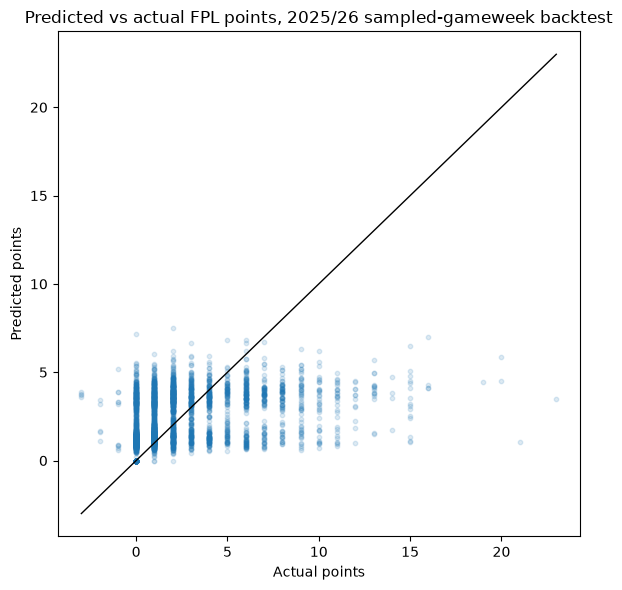

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(points_df["actual_points"], points_df["predicted_points"], alpha=0.15, s=10)
lims = [points_df["actual_points"].min(), points_df["actual_points"].max()]
ax.plot(lims, lims, color="black", linewidth=1)
ax.set_xlabel("Actual points")
ax.set_ylabel("Predicted points")
ax.set_title("Predicted vs actual FPL points, 2025/26 sampled-gameweek backtest")
fig.tight_layout()

### Points accuracy by actual minutes played

Splits out whether prediction quality depends on how much the player actually played -
the case the minutes model is meant to help most with (rows where the player barely
featured or played the full match, vs. partial appearances where minutes uncertainty
matters most).

In [15]:
minutes_bucket = pd.cut(
    points_df["actual_minutes"],
    bins=[-1, 0, 59, 89, 90],
    labels=["0", "1-59", "60-89", "90"],
)
points_df.assign(bucket=minutes_bucket, abs_error=points_error).groupby(
    "bucket", observed=True
)["abs_error"].agg(["mean", "count"]).rename(columns={"mean": "MAE"})

,MAE,count
bucket,,
0,1.075782,4534
1-59,1.102608,914
60-89,2.201266,594
90,2.512186,1319


## Caveats

- This only evaluates *minutes* accuracy, not downstream points accuracy. The points-scoring formulas
  (e.g. `get_attacking_points`) scale continuously with `minutes / 90`, so the within-bucket regressors do
  feed into predicted points - but this notebook only checks the minutes number itself, not the final
  points output.
- FPL positions are coarse (e.g. left-back and centre-back aren't distinguished), so "same position" here
  is an approximation of "direct competitor for the same starting slot", not a real depth chart.
- `absent_teammates_typical_minutes` skips zero-minute rows when estimating a teammate's typical minutes,
  rather than anchoring to the exact gameweek their absence started (`Absence.gw_from`) - a simpler
  approximation that stays symmetric between this historical backtest and live current-season serving
  (which has no equivalent "injury start gameweek" field). See the module docstring in
  `minutes_model.py` for more.
- The historical `Absence` data is TransferMarkt-derived and known to have some gaps/errors - see
  `notebooks/minutes_estimation_data.ipynb` for examples found during data cleaning.